# Video preprocessing with barcoded videos
Barcoded videos are used with highspeed cameras where each frame has an LED bar present. The pattern of LEDs is a barcode, which is delivered in a serialized manner to your data acquistion system. The template goes through the steps of:
1. Compiling the image frames into a video
2. Extracting the barcode from each frame
3. Aligning the frame barcodes to the times in the serialized signal, which will be in the same time space as your neural recordings
4. Creating 'region of interest' videos for later processing with DeepLabCut

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from mimo_pack.preprocess.video import tif_to_video, create_video_rois, track_video_rois, rois_to_barcodes, extract_rois_to_videos
from mimo_pack.preprocess.time import align_sync_video_barcode

## Specify file paths

In [ ]:
# directory where your images from the experiment are located
img_dir = "W:\\Drew\\25-01-20_ZS02_Reach\\"

# Path to dclut file with the time code for your neural data. It is best to use the dclut file that was
# used as the reference for all other recording files
dcl_path = "D:\\SortingTemp\\25-01-20_ZS02_Reach_g0_imec0\\25-01-20_ZS02_Reach_g0_t0.imec0.ap_dclut.json"


## 1. Convert directory of images to video


In [ ]:
# convert the .tif files to a single .mp4 video file
vid_path, tbl_path = tif_to_video(img_dir)

## 2. Create barcode from video

In [ ]:
rois = create_video_rois(vid_path)

100%|██████████| 51667/51667 [04:25<00:00, 194.82it/s]


Text(0.5, 1.0, 'Barcodes Across Frames')

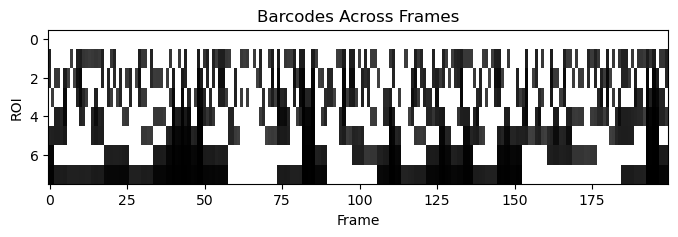

In [ ]:
roi_df = track_video_rois(vid_path, tbl_path, rois=rois)

# Visualize barcode signals for the the first 500 frames. 
roi_vals = roi_df.values
fig, ax = plt.subplots(figsize=(8, 2))
plt.imshow(255-roi_vals[:200].T, aspect='auto', cmap='gray', interpolation='none')
ax.set_ylabel('ROI')
ax.set_xlabel('Frame')
ax.set_title('Barcodes Across Frames')

In [ ]:
barcode = rois_to_barcodes(tbl_path, roi_cols=['roi_' + str(i) for i in range(8)])

## 3. Align with dclut reference

In [ ]:
tbl_path = align_sync_video_barcode(tbl_path, dcl_path, 'barcode',  {'channel': [384]}, 'time', verbose=True)

(-1.0, 2.0)

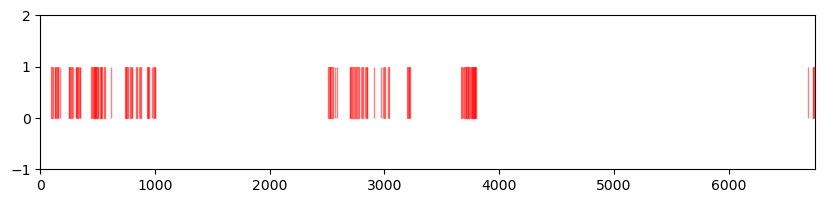

In [ ]:
# confirm that highspeed camera egments are identified that were aligned with neural data
vid_df = pd.read_csv(tbl_path)

# display video data
segs_df = vid_df.groupby('epoch_num')['time'].agg(['min', 'max']).reset_index()
segs_df

# create a function that takes a list of start and end timepoints for video segmens and plots rectangles on an axis inicating the video segmens
def plot_video_segments(ax, start_times, end_times, color='red', alpha=0.5):
    for start, end in zip(start_times, end_times):
        ax.add_patch(plt.Rectangle((start, 0), end - start, 1, color=color, alpha=alpha))

fig, ax = plt.subplots(figsize=(10, 2))
plot_video_segments(ax, segs_df['min'].values, segs_df['max'].values)
ax.set_xlim(0, vid_df['time'].max())
ax.set_ylim(-1, 2)

## 4. Extract ROIs from videos.

In [ ]:
vid_rois_path = extract_rois_to_videos(vid_path, display_frame=0, output_dir=None)

error: OpenCV(4.11.0) D:\a\opencv-python\opencv-python\opencv\modules\highgui\src\window.cpp:868: error: (-215:Assertion failed) trackbar in function 'cv::getTrackbarPos'


Saved 2 ROI video(s):
D:\SortingTemp\25-01-20_ZS02_Reach_roi_1.mp4
D:\SortingTemp\25-01-20_ZS02_Reach_roi_2.mp4
